# Phrase-Level Mapping Analyse

Dieses Notebook analysiert die explorative vierte Matching-Methode `build_mapping_phrases.py`.

Im Unterschied zu den Wortmethoden erlaubt diese Methode n-gram-Mappings wie:

- `HD 1-gram -> IPA 2-gram`
- `HD 2-gram -> IPA 1-gram`
- `HD 2-gram -> IPA 2-gram`

Ziel ist nicht, die bisherigen Methoden zu ersetzen, sondern Mehrwort- und Kontraktionsfälle im Schweizerdeutschen sichtbar zu machen.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"

PHRASE_CSV = DATA_DIR / "ostschweiz_mapping_phrases.csv"
ANNOTATION_CSV = DATA_DIR / "annotation_candidates.csv"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 150)

## Daten Laden

In [2]:
phrases = pd.read_csv(PHRASE_CSV)
phrases["Is_Phrase_Mapping"] = phrases["Is_Phrase_Mapping"].astype(int)

phrase_only = phrases[phrases["Is_Phrase_Mapping"] == 1].copy()
word_only = phrases[phrases["Is_Phrase_Mapping"] == 0].copy()

print(f"Kandidaten total: {len(phrases)}")
print(f"1-1 Wort-Kandidaten: {len(word_only)}")
print(f"echte Phrase-Kandidaten: {len(phrase_only)}")
print(f"eindeutige HD-Phrasen: {phrases['HD_Phrase'].nunique()}")

Kandidaten total: 170
1-1 Wort-Kandidaten: 128
echte Phrase-Kandidaten: 42
eindeutige HD-Phrasen: 159


## Mapping-Typen

In [3]:
type_counts = (
    phrases["Mapping_Type"]
    .value_counts()
    .sort_index()
    .rename_axis("Mapping_Type")
    .reset_index(name="count")
)
display(type_counts)

,Mapping_Type,count
0,1-1,128
1,1-2,2
2,2-1,29
3,2-2,10
4,3-1,1


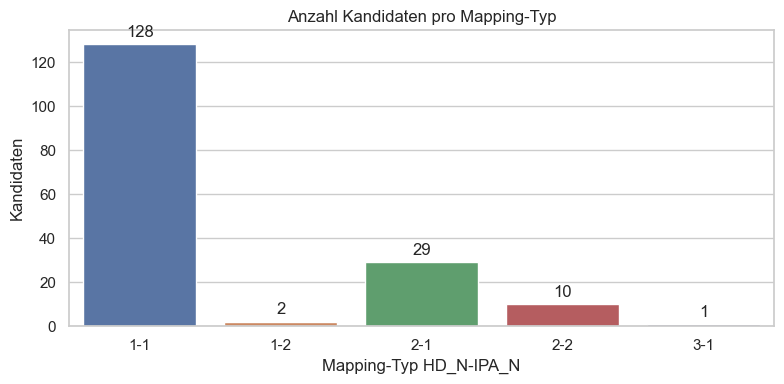

In [4]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=type_counts, x="Mapping_Type", y="count", hue="Mapping_Type", dodge=False, legend=False)
ax.set_title("Anzahl Kandidaten pro Mapping-Typ")
ax.set_xlabel("Mapping-Typ HD_N-IPA_N")
ax.set_ylabel("Kandidaten")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

## Top Phrase-Kandidaten

Diese Tabelle ist der wichtigste Teil: Hier stehen nur Kandidaten, bei denen mindestens eine Seite mehr als ein Token enthält.

In [5]:
main_cols = [
    "HD_Phrase",
    "IPA_Phrase",
    "Mapping_Type",
    "Gemeinsame_Treffer",
    "HD_Rate",
    "IPA_Rate",
    "PMI",
    "Avg_Position_Distance",
    "Score",
]

display(phrase_only[main_cols].head(50))

,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,HD_Rate,IPA_Rate,PMI,Avg_Position_Distance,Score
15,für die,fyːɾ,2-1,30,0.4615,0.2830,3.7472,0.0624,105.4056
22,für die,fyːɾ diː,2-2,14,0.2154,0.8235,5.2881,0.0477,70.5051
42,haben sich,hɛnt zɪç,2-2,5,0.7143,1.0000,8.7832,0.0489,41.7691
55,die beiden,baɪdə,2-1,5,0.7143,0.5556,7.9352,0.0541,37.5309
63,er ist,ɛr,2-1,4,0.5714,1.0000,8.7832,0.0783,32.3810
65,haben wir,hɛm,2-1,5,0.2778,0.6250,6.7426,0.0555,31.8428
66,mehr als,meː als,2-2,4,0.4000,1.0000,8.2687,0.0614,31.0451
77,und für,ʊnt fyːɾ,2-2,3,1.0000,1.0000,10.0056,0.0583,28.2659
78,mehr als,meː,2-1,5,0.5000,0.2273,6.1312,0.0782,28.2591
81,auch der,aʊtə,2-1,4,0.3636,0.5714,7.3238,0.0421,28.0623


## Nach Mapping-Typ Getrennt

In [6]:
for mapping_type in sorted(phrase_only["Mapping_Type"].unique()):
    print("\n" + "=" * 80)
    print(mapping_type)
    display(phrase_only[phrase_only["Mapping_Type"] == mapping_type][main_cols].head(20))


1-2


,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,HD_Rate,IPA_Rate,PMI,Avg_Position_Distance,Score
110,rahmen,ɪm rɑːmə,1-2,3,0.6000,1.0,9.2687,0.1024,24.9600
113,finde,ɪç fɪnt,1-2,3,0.3333,1.0,8.4207,0.0344,24.3932



2-1


,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,HD_Rate,IPA_Rate,PMI,Avg_Position_Distance,Score
15,für die,fyːɾ,2-1,30,0.4615,0.2830,3.7472,0.0624,105.4056
55,die beiden,baɪdə,2-1,5,0.7143,0.5556,7.9352,0.0541,37.5309
63,er ist,ɛr,2-1,4,0.5714,1.0000,8.7832,0.0783,32.3810
65,haben wir,hɛm,2-1,5,0.2778,0.6250,6.7426,0.0555,31.8428
78,mehr als,meː,2-1,5,0.5000,0.2273,6.1312,0.0782,28.2591
81,auch der,aʊtə,2-1,4,0.3636,0.5714,7.3238,0.0421,28.0623
85,plus von,blʊs,2-1,3,1.0000,1.0000,10.0056,0.0802,27.6102
90,nicht ganz,gants,2-1,4,0.5714,0.3333,7.1983,0.0569,27.1544
93,im rahmen,rɑːmə,2-1,3,0.7500,1.0000,9.5906,0.0713,26.7190
103,die zahl,tsɑːl,2-1,3,0.6000,1.0000,9.2687,0.0725,25.7904



2-2


,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,HD_Rate,IPA_Rate,PMI,Avg_Position_Distance,Score
22,für die,fyːɾ diː,2-2,14,0.2154,0.8235,5.2881,0.0477,70.5051
42,haben sich,hɛnt zɪç,2-2,5,0.7143,1.0000,8.7832,0.0489,41.7691
66,mehr als,meː als,2-2,4,0.4000,1.0000,8.2687,0.0614,31.0451
77,und für,ʊnt fyːɾ,2-2,3,1.0000,1.0000,10.0056,0.0583,28.2659
96,im rahmen,ɪm rɑːmə,2-2,3,0.7500,1.0000,9.5906,0.0868,26.2757
107,ich finde,ɪç fɪnt,2-2,3,0.4286,1.0000,8.7832,0.0381,25.3459
121,hat sich,hɛt zɪç,2-2,4,0.2105,0.4444,6.1727,0.0452,23.5743
129,sich in,zɪç ɪn,2-2,3,0.3333,0.7500,8.0056,0.0718,22.2934
156,und die,ʊnt diː,2-2,3,0.2308,0.3333,6.3052,0.0163,18.6069
159,für den,fyːɾ dɛɾ,2-2,3,0.1500,0.7500,6.8536,0.1027,18.4499



3-1


,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,HD_Rate,IPA_Rate,PMI,Avg_Position_Distance,Score
99,die zahl der,tsɑːl,3-1,3,0.75,1.0,9.5906,0.091,26.1534


## Beispielkontexte

Diese Ansicht ist hilfreich, um schnell zu entscheiden, ob ein Kandidat wirklich eine Dialektentsprechung ist oder nur ein Positions-/Kookkurrenzartefakt.

In [7]:
context_cols = [
    "HD_Phrase",
    "IPA_Phrase",
    "Mapping_Type",
    "Gemeinsame_Treffer",
    "Score",
    "Example_Sentence",
    "Example_IPA_Audio",
    "Example_IPA_Reference",
    "Example_Tense",
]

display(phrase_only[context_cols].head(30))

,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,Score,Example_Sentence,Example_IPA_Audio,Example_IPA_Reference,Example_Tense
15,für die,fyːɾ,2-1,30,105.4056,Es gäbe sicher lohnenswerte Ziele für die nächsten Jahre.,ɛs gɛp sɪç loːnən tsvɛɾt diː tsiːl fyːɾ diː nɔɾstɛ jɔː,ɛs ɡɛːbə zɪçɜ loːnənsveːɾtə tsiːlə fyːɾ diː nɛçstən jɑːrə,Präsens
22,für die,fyːɾ diː,2-2,14,70.5051,Es gäbe sicher lohnenswerte Ziele für die nächsten Jahre.,ɛs gɛp sɪç loːnən tsvɛɾt diː tsiːl fyːɾ diː nɔɾstɛ jɔː,ɛs ɡɛːbə zɪçɜ loːnənsveːɾtə tsiːlə fyːɾ diː nɛçstən jɑːrə,Präsens
42,haben sich,hɛnt zɪç,2-2,5,41.7691,Und neue Türen haben sich nicht geöffnet.,ʊnt nɔødyːrə hɛnt zɪç nøkəlfnɛt,ʊnt nɔøə tyːrən hɑːbən zɪç nɪçt ɡəœfnət,Perfekt
55,die beiden,baɪdə,2-1,5,37.5309,Sie zeigen die beiden Entführten vor einem grossen schwarzen Banner sitzend.,ɛs tsaɪgɪ baɪdə ɛntfyːrə woːfɑːm neː goːsɪʃ vɑːtsə bɑːnə ziːtsət,ziː tsaɪɡən diː baɪdən ɛntfyːɾtən fɔɾ aɪnəm ɡɾɔsən ʃvaɾtsən banɜ zɪtsənt,Präsens
63,er ist,ɛr,2-1,4,32.3810,"Er ist verheiratet, hat drei erwachsene Kinder und zwei Enkel.",ɛr ɪʃ kʊvyːrɑːtət heːt dɾaɪɛɾ vaxzɪnə kɪnd ʊnt tsvaɪ ɛnkəl,ɛɾ ɪst fɛɾhaɪrɑːtət hat dɾaɪ ɛɾvaxzənə kɪndɜ ʊnt tsvaɪ ɛnkəl,Präsens
65,haben wir,hɛm,2-1,5,31.8428,"Deshalb haben wir uns ja bereits entschieden, ein solches Alterszentrum zu bauen.",dɑːrʊŋ hɛm miːryːsaʊ bəraɪts ɛntʃiːdə eːzøːtɪks altʊs tsɛnt dʊmt tsvaʊən,dɛshalp hɑːbən viːɾ ʊns jɑː bəraɪts ɛntʃiːdən aɪn zɔlçəs altɜstsɛntɾʊm tsuː baʊən,Präsens
66,mehr als,meː als,2-2,4,31.0451,Jedes Jahr reisen mehr als 35 Millionen Touristen nach Thailand.,jeːdəs jɑːɾ als meː als fœfətɾɪsk mɪliːɔːnə duː viːɾʃtə ɔftɛɪlɛnt,jeːdəs jɑːɾ raɪzən meːɾ als fʏnf ʊntdɾaɪsɪç mɪljoːnən tuːrɪstən nɑːx taɪlant,Präsens
77,und für,ʊnt fyːɾ,2-2,3,28.2659,Und für das müssen nicht sieben Jahre lang Abklärungen gemacht werden.,ʊnt fyːɾ taːx myːn nyːtsɪbə jɔːrlɑŋ apglɛːrɪgə gmaxt vɛɾdə,ʊnt fyːɾ das mʏsən nɪçt ziːbən jɑːrə laŋ apklɛːrʊŋən ɡəmaxt vɛɾdən,Futur
78,mehr als,meː,2-1,5,28.2591,Jedes Jahr reisen mehr als 35 Millionen Touristen nach Thailand.,jeːdəs jɑːɾ als meː als fœfətɾɪsk mɪliːɔːnə duː viːɾʃtə ɔftɛɪlɛnt,jeːdəs jɑːɾ raɪzən meːɾ als fʏnf ʊntdɾaɪsɪç mɪljoːnən tuːrɪstən nɑːx taɪlant,Präsens
81,auch der,aʊtə,2-1,4,28.0623,Die Preisdifferenz erachtet auch der Stadtrat als zu gross.,pɾiːstəfərɛnts ɛɾɑːxdət aʊtə ʃtatɾɑːt aʊst tsuːkɔs,diː pɾaɪsdɪfeːrɛnts ɛɾaxtət aʊx dɛɾ ʃtatɾɑːt als tsuː ɡɾɔs,Präsens


## Kandidaten Mit Potenzieller Kontraktion

`2-1` und `3-1` sind besonders interessant, weil mehrere HD-Wörter in einem IPA-Token zusammenfallen können.

In [8]:
contractions = phrase_only[phrase_only["IPA_N"] == 1].copy()
display(contractions[context_cols].head(40))

,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,Score,Example_Sentence,Example_IPA_Audio,Example_IPA_Reference,Example_Tense
15,für die,fyːɾ,2-1,30,105.4056,Es gäbe sicher lohnenswerte Ziele für die nächsten Jahre.,ɛs gɛp sɪç loːnən tsvɛɾt diː tsiːl fyːɾ diː nɔɾstɛ jɔː,ɛs ɡɛːbə zɪçɜ loːnənsveːɾtə tsiːlə fyːɾ diː nɛçstən jɑːrə,Präsens
55,die beiden,baɪdə,2-1,5,37.5309,Sie zeigen die beiden Entführten vor einem grossen schwarzen Banner sitzend.,ɛs tsaɪgɪ baɪdə ɛntfyːrə woːfɑːm neː goːsɪʃ vɑːtsə bɑːnə ziːtsət,ziː tsaɪɡən diː baɪdən ɛntfyːɾtən fɔɾ aɪnəm ɡɾɔsən ʃvaɾtsən banɜ zɪtsənt,Präsens
63,er ist,ɛr,2-1,4,32.3810,"Er ist verheiratet, hat drei erwachsene Kinder und zwei Enkel.",ɛr ɪʃ kʊvyːrɑːtət heːt dɾaɪɛɾ vaxzɪnə kɪnd ʊnt tsvaɪ ɛnkəl,ɛɾ ɪst fɛɾhaɪrɑːtət hat dɾaɪ ɛɾvaxzənə kɪndɜ ʊnt tsvaɪ ɛnkəl,Präsens
65,haben wir,hɛm,2-1,5,31.8428,"Deshalb haben wir uns ja bereits entschieden, ein solches Alterszentrum zu bauen.",dɑːrʊŋ hɛm miːryːsaʊ bəraɪts ɛntʃiːdə eːzøːtɪks altʊs tsɛnt dʊmt tsvaʊən,dɛshalp hɑːbən viːɾ ʊns jɑː bəraɪts ɛntʃiːdən aɪn zɔlçəs altɜstsɛntɾʊm tsuː baʊən,Präsens
78,mehr als,meː,2-1,5,28.2591,Jedes Jahr reisen mehr als 35 Millionen Touristen nach Thailand.,jeːdəs jɑːɾ als meː als fœfətɾɪsk mɪliːɔːnə duː viːɾʃtə ɔftɛɪlɛnt,jeːdəs jɑːɾ raɪzən meːɾ als fʏnf ʊntdɾaɪsɪç mɪljoːnən tuːrɪstən nɑːx taɪlant,Präsens
81,auch der,aʊtə,2-1,4,28.0623,Die Preisdifferenz erachtet auch der Stadtrat als zu gross.,pɾiːstəfərɛnts ɛɾɑːxdət aʊtə ʃtatɾɑːt aʊst tsuːkɔs,diː pɾaɪsdɪfeːrɛnts ɛɾaxtət aʊx dɛɾ ʃtatɾɑːt als tsuː ɡɾɔs,Präsens
85,plus von,blʊs,2-1,3,27.6102,"Dies entspricht einem Plus von 0,4 Prozent.",taɪs ɛnʃpɾɪçt fɔm neː blʊs foː nʊɾ kɔm ɪnfɪɾ pɔtsɛnt,diːs ɛntʃpɾɪçt aɪnəm plʊs fɔn nʊl fiːɾ pɾoːtsɛnt,Präsens
90,nicht ganz,gants,2-1,4,27.1544,Cannabis ist in Bezug auf Psychose nicht ganz ohne.,kɑnɑpɪs ɪn bɪtsuːkɔf pɪsɪxɔsɛ nøk gants ɔnɪ,kanabɪs ɪst ɪn bətsuːk aʊf pzʏçoːzə nɪçt ɡants oːnə,Präsens
93,im rahmen,rɑːmə,2-1,3,26.7190,Ein weiterer Mann wurde im Rahmen einer Fahndung identifiziert und gestellt.,ɛn vɪktərə mɑːɾ ɪç ɪm rɑːmə fɔnɔxfɑːndɪç iːdɛntifiːɾt ʊntgʃtɛlt vɔɾdə,aɪn vaɪtərɜ man vʊɐdə ɪm rɑːmən aɪnɜ fɑːndʊŋ iːdəntiːfiːtsiːɾt ʊnt ɡəʃtɛlt,Präteritum
99,die zahl der,tsɑːl,3-1,3,26.1534,"Die Zahl der Angestellten stieg zwar um 1,1 Prozent auf 971.",tsɑːl fɔɾ dɑːɾ aɾgʃtɛltən ɪnz aɪgɛnlɪçɔm aɪskɾʊmɑː aɪspoːtsɛnt dʊfniːx oːnət aɪnɪs ɪbɛts gʃtiːgən,diː tsɑːl dɛɾ anɡəʃtɛltən ʃtiːk tsvɑːɾ ʊm aɪns aɪns pɾoːtsɛnt aʊf nɔønhʊndɜt aɪn ʊntziːptsɪç,Präteritum


## Vergleich Mit Annotierten 1-1-Mappings

Hier wird grob geprüft, ob ein Phrase-Kandidat einzelne bereits korrekt annotierte Wortpaare enthält. Das ist keine Evaluation, sondern eine Orientierung: Kandidaten ohne bekannte Teilmappings sind oft interessanter für die Fehleranalyse.

In [9]:
annotations = pd.read_csv(ANNOTATION_CSV, keep_default_na=False)
correct_pairs = set(
    zip(
        annotations.loc[annotations["correct"] == "1", "Hochdeutsch"].astype(str),
        annotations.loc[annotations["correct"] == "1", "IPA_Dialekt"].astype(str),
    )
)

def count_known_subpairs(row):
    hd_tokens = str(row["HD_Phrase"]).split()
    ipa_tokens = str(row["IPA_Phrase"]).split()
    return sum((hd, ipa) in correct_pairs for hd in hd_tokens for ipa in ipa_tokens)

phrase_only["Known_Correct_Subpairs"] = phrase_only.apply(count_known_subpairs, axis=1)
phrase_only["Has_Known_Correct_Subpair"] = phrase_only["Known_Correct_Subpairs"] > 0

display(
    phrase_only[[*main_cols, "Known_Correct_Subpairs", "Has_Known_Correct_Subpair"]]
    .sort_values(["Has_Known_Correct_Subpair", "Score"], ascending=[True, False])
    .head(40)
)

,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,HD_Rate,IPA_Rate,PMI,Avg_Position_Distance,Score,Known_Correct_Subpairs,Has_Known_Correct_Subpair
63,er ist,ɛr,2-1,4,0.5714,1.0000,8.7832,0.0783,32.3810,0,False
65,haben wir,hɛm,2-1,5,0.2778,0.6250,6.7426,0.0555,31.8428,0,False
81,auch der,aʊtə,2-1,4,0.3636,0.5714,7.3238,0.0421,28.0623,0,False
85,plus von,blʊs,2-1,3,1.0000,1.0000,10.0056,0.0802,27.6102,0,False
93,im rahmen,rɑːmə,2-1,3,0.7500,1.0000,9.5906,0.0713,26.7190,0,False
99,die zahl der,tsɑːl,3-1,3,0.7500,1.0000,9.5906,0.0910,26.1534,0,False
103,die zahl,tsɑːl,2-1,3,0.6000,1.0000,9.2687,0.0725,25.7904,0,False
104,zahl der,tsɑːl,2-1,3,0.7500,1.0000,9.5906,0.1095,25.6206,0,False
110,rahmen,ɪm rɑːmə,1-2,3,0.6000,1.0000,9.2687,0.1024,24.9600,0,False
122,ist die,ɪst,2-1,5,0.2500,0.2083,5.0056,0.0609,23.5051,0,False


## Suchhilfe Für Einzelne Ausdrücke

In [10]:
search_terms = ["dafür", "immer", "nicht", "nicht mehr", "waren", "gibt es", "haben sich", "für die"]

for term in search_terms:
    sub = phrases[phrases["HD_Phrase"].str.contains(term, regex=False, na=False)]
    print("\n" + "=" * 80)
    print(f"{term}: {len(sub)} Treffer")
    if not sub.empty:
        display(sub[context_cols].head(20))


dafür: 0 Treffer

immer: 0 Treffer

nicht: 3 Treffer


,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,Score,Example_Sentence,Example_IPA_Audio,Example_IPA_Reference,Example_Tense
86,nichts,nyːd,1-1,4,27.3510,Nichts geändert haben die Japaner allerdings am Motor.,nyːd kɛndrɛt hɛnt jɑpɑːn ɑːlədɪŋ sɑːmɑːtoː,nɪçts ɡəɛndɜt hɑːbən diː japɑːnɜ alɜdɪŋs am moːtoːɾ,Perfekt
90,nicht ganz,gants,2-1,4,27.1544,Cannabis ist in Bezug auf Psychose nicht ganz ohne.,kɑnɑpɪs ɪn bɪtsuːkɔf pɪsɪxɔsɛ nøk gants ɔnɪ,kanabɪs ɪst ɪn bətsuːk aʊf pzʏçoːzə nɪçt ɡants oːnə,Präsens
167,nicht in,nøːt,2-1,3,16.4537,"Und das wollen wir in Aarau nicht, auch nicht in der Zwischensaison.",ʊnt ʊntɑs vømeːrɪn ɑːraʊ nøːt ɑːnøːtɪtɪ tə tsvɪʃɛzəzɑːn,ʊnt das vɔlən viːɾ ɪn ɑːraʊ nɪçt aʊx nɪçt ɪn dɛɾ tsvɪʃənzaɪzoːn,Präsens



nicht mehr: 0 Treffer

waren: 0 Treffer

gibt es: 2 Treffer


,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,Score,Example_Sentence,Example_IPA_Audio,Example_IPA_Reference,Example_Tense
138,gibt es,gits,2-1,3,21.0561,Zum Schweizer Preis gibt es noch keine konkreten Angaben.,tsuʒuitse prɛz gits nokraʎ kɔn kɾɛtʃ ɛɾkɔp,tsʊm ʃvaɪtsɜ pɾaɪs ɡiːpt ɛs nɔx kaɪnə kɔŋkɾeːtən anɡɑːbən,Präsens
147,gibt es,giːts,2-1,3,20.0289,Im Fussball gibt es immer etwas Neues zu erzählen.,ɪm vʊɐspal giːts iːmɑː øːbɪs nɔøst fɔtseːlə,ɪm fʊsbal ɡiːpt ɛs ɪmɜ ɛtvɑːs nɔøəs tsuː ɛɾtsɛːlən,Präsens



haben sich: 1 Treffer


,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,Score,Example_Sentence,Example_IPA_Audio,Example_IPA_Reference,Example_Tense
42,haben sich,hɛnt zɪç,2-2,5,41.7691,Und neue Türen haben sich nicht geöffnet.,ʊnt nɔødyːrə hɛnt zɪç nøkəlfnɛt,ʊnt nɔøə tyːrən hɑːbən zɪç nɪçt ɡəœfnət,Perfekt



für die: 2 Treffer


,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,Score,Example_Sentence,Example_IPA_Audio,Example_IPA_Reference,Example_Tense
15,für die,fyːɾ,2-1,30,105.4056,Es gäbe sicher lohnenswerte Ziele für die nächsten Jahre.,ɛs gɛp sɪç loːnən tsvɛɾt diː tsiːl fyːɾ diː nɔɾstɛ jɔː,ɛs ɡɛːbə zɪçɜ loːnənsveːɾtə tsiːlə fyːɾ diː nɛçstən jɑːrə,Präsens
22,für die,fyːɾ diː,2-2,14,70.5051,Es gäbe sicher lohnenswerte Ziele für die nächsten Jahre.,ɛs gɛp sɪç loːnən tsvɛɾt diː tsiːl fyːɾ diː nɔɾstɛ jɔː,ɛs ɡɛːbə zɪçɜ loːnənsveːɾtə tsiːlə fyːɾ diː nɛçstən jɑːrə,Präsens


## Review-Sample

Falls die Phrase-Methode in der Arbeit erwähnt wird, würde ich nicht alle Kandidaten annotieren. Sinnvoller ist eine kleine qualitative Prüfung der besten echten Phrase-Kandidaten.

In [11]:
review_sample = phrase_only.sort_values("Score", ascending=False).head(30).copy()
review_sample = review_sample.assign(correct="", comment="")
review_cols = [
    "HD_Phrase",
    "IPA_Phrase",
    "Mapping_Type",
    "Gemeinsame_Treffer",
    "Score",
    "Example_Sentence",
    "Example_IPA_Audio",
    "correct",
    "comment",
]
display(review_sample[review_cols])

,HD_Phrase,IPA_Phrase,Mapping_Type,Gemeinsame_Treffer,Score,Example_Sentence,Example_IPA_Audio,correct,comment
15,für die,fyːɾ,2-1,30,105.4056,Es gäbe sicher lohnenswerte Ziele für die nächsten Jahre.,ɛs gɛp sɪç loːnən tsvɛɾt diː tsiːl fyːɾ diː nɔɾstɛ jɔː,,
22,für die,fyːɾ diː,2-2,14,70.5051,Es gäbe sicher lohnenswerte Ziele für die nächsten Jahre.,ɛs gɛp sɪç loːnən tsvɛɾt diː tsiːl fyːɾ diː nɔɾstɛ jɔː,,
42,haben sich,hɛnt zɪç,2-2,5,41.7691,Und neue Türen haben sich nicht geöffnet.,ʊnt nɔødyːrə hɛnt zɪç nøkəlfnɛt,,
55,die beiden,baɪdə,2-1,5,37.5309,Sie zeigen die beiden Entführten vor einem grossen schwarzen Banner sitzend.,ɛs tsaɪgɪ baɪdə ɛntfyːrə woːfɑːm neː goːsɪʃ vɑːtsə bɑːnə ziːtsət,,
63,er ist,ɛr,2-1,4,32.3810,"Er ist verheiratet, hat drei erwachsene Kinder und zwei Enkel.",ɛr ɪʃ kʊvyːrɑːtət heːt dɾaɪɛɾ vaxzɪnə kɪnd ʊnt tsvaɪ ɛnkəl,,
65,haben wir,hɛm,2-1,5,31.8428,"Deshalb haben wir uns ja bereits entschieden, ein solches Alterszentrum zu bauen.",dɑːrʊŋ hɛm miːryːsaʊ bəraɪts ɛntʃiːdə eːzøːtɪks altʊs tsɛnt dʊmt tsvaʊən,,
66,mehr als,meː als,2-2,4,31.0451,Jedes Jahr reisen mehr als 35 Millionen Touristen nach Thailand.,jeːdəs jɑːɾ als meː als fœfətɾɪsk mɪliːɔːnə duː viːɾʃtə ɔftɛɪlɛnt,,
77,und für,ʊnt fyːɾ,2-2,3,28.2659,Und für das müssen nicht sieben Jahre lang Abklärungen gemacht werden.,ʊnt fyːɾ taːx myːn nyːtsɪbə jɔːrlɑŋ apglɛːrɪgə gmaxt vɛɾdə,,
78,mehr als,meː,2-1,5,28.2591,Jedes Jahr reisen mehr als 35 Millionen Touristen nach Thailand.,jeːdəs jɑːɾ als meː als fœfətɾɪsk mɪliːɔːnə duː viːɾʃtə ɔftɛɪlɛnt,,
81,auch der,aʊtə,2-1,4,28.0623,Die Preisdifferenz erachtet auch der Stadtrat als zu gross.,pɾiːstəfərɛnts ɛɾɑːxdət aʊtə ʃtatɾɑːt aʊst tsuːkɔs,,


## Kurzfazit

In [12]:
top_phrase = phrase_only.iloc[0]
top_contraction = contractions.iloc[0] if not contractions.empty else None

print(
    f"Die Phrase-Methode erzeugt {len(phrases)} Kandidaten, davon "
    f"{len(phrase_only)} echte Phrase-Mappings."
)
print(
    f"Der stärkste Phrase-Kandidat ist '{top_phrase['HD_Phrase']} -> {top_phrase['IPA_Phrase']}' "
    f"({top_phrase['Mapping_Type']}, Score={top_phrase['Score']:.2f})."
)
if top_contraction is not None:
    print(
        f"Der stärkste Kontraktionskandidat ist '{top_contraction['HD_Phrase']} -> {top_contraction['IPA_Phrase']}' "
        f"({top_contraction['Mapping_Type']})."
    )
print(
    "Für den Bericht eignet sich diese Methode als qualitative Zusatzanalyse: "
    "Sie findet mehrere plausible Mehrwort- und Kontraktionsfälle, ist aber nicht direkt mit der Wort-Precision vergleichbar."
)

Die Phrase-Methode erzeugt 170 Kandidaten, davon 42 echte Phrase-Mappings.
Der stärkste Phrase-Kandidat ist 'für die -> fyːɾ' (2-1, Score=105.41).
Der stärkste Kontraktionskandidat ist 'für die -> fyːɾ' (2-1).
Für den Bericht eignet sich diese Methode als qualitative Zusatzanalyse: Sie findet mehrere plausible Mehrwort- und Kontraktionsfälle, ist aber nicht direkt mit der Wort-Precision vergleichbar.
